<a href="https://colab.research.google.com/github/preesr/quantum-computing/blob/main/Quantum_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install 'qiskit[visualization]' qiskit-ibm-runtime qiskit-aer
# Core Qiskit imports
from qiskit import QuantumCircuit # Need this to build quantum programs, define qubits, and perform operations
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager # for optimizing the hardware

# IBM Runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService #ibm runtime service in IBM cloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.7/120.7 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.7/94.7 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541

1. Map the problem to a model that can be represented by quantum circuits
2. Optimize the circuit to be run on a specific backend
3. Execute the optimized circuit on the selected backend
4. Post-process the raw measurement data

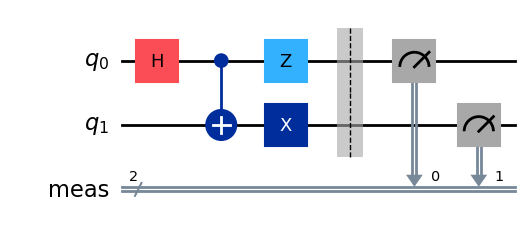

In [21]:
'''
Physics experiment: Two interacting magnets.
If we prepare the spins in a particular state, what is the energy of that state?

To answer this, we will:

Prepare the spins in a state of our choosing which is
state psi minus = (1/√2) (|10> -|01>)

Measure the energy of that state using the Hamiltonian object
which tells us the energy of the system.

'''


# Experiment 1: Use Sampler to measure the state
# Import IBM Quantum primitives
from qiskit import QuantumCircuit

# Make state phi minus = (1/√2) (|10> -|01>)
qc = QuantumCircuit(2) # initiate quantum circuit
# Create superposition of q0 with Hadamard. You get (1/√2) (|00> + |01>)
qc.h(0)
# CNOT on Hadamard gives you entangled q1. You get (1/√2) (|00> + |11>)
# i.e. the bell state
qc.cx(0, 1)
# Pauli-X on q1. Acts as NOT gate. You get (1/√2) (|01> + |10>) which is same as
#(1/√2) (|10> + |01>)
qc.x(1)
# Pauli-Z on q0. q0 remains unchanged but multiples q1 with -1
# You get (1/√2) (|10> - |01>)
qc.z(0)

# Measure state
qc.measure_all()

# Draw circuit
qc.draw("mpl")

In [5]:
# Load IBM Quantum Compute Service
from qiskit_ibm_runtime import QiskitRuntimeService

## Load IBM Quantum Compute Service
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="",
    overwrite=True,
    set_as_default=True,
 )
service = QiskitRuntimeService(channel="ibm_quantum_platform")


# Or load saved credentials
service = QiskitRuntimeService()

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_brisbane".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend("ibm_brisbane")
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-08-17 22:41:10,182: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.__init__:WARNING:2026-08-17 22:41:12,152: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default insta

ibm_kingston


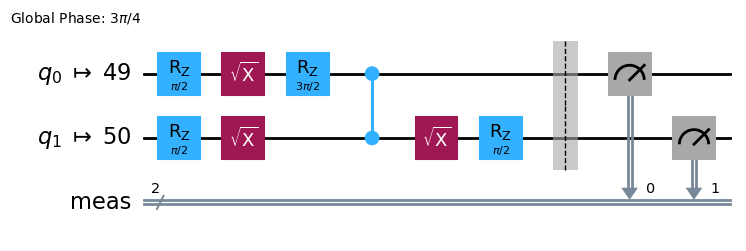

In [8]:
# Transpile the circuit and optimize for running on the quantum computer selected
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

qc_isa.draw("mpl")

In [9]:
# Load the Runtime primitive and session
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)

In [ ]:
## Load the backend sampler
from qiskit.primitives import BackendSamplerV2

## Load the Aer simulator and generate a noise model based on the currently-selected backend.
##from qiskit_aer import AerSimulator
##from qiskit_aer.noise import NoiseModel

##noise_model = NoiseModel.from_backend(backend)

## Define a simulator using Aer, and use it in Sampler.
##backend_sim = AerSimulator(noise_model=noise_model)
##sampler_sim = BackendSamplerV2(backend=backend_sim)

## Alternatively, load a fake backend with generic properties and define a simulator.
## backend_gen = GenericBackendV2(num_qubits=18)
## sampler_gen = BackendSamplerV2(backend=backend_gen)

In [10]:
job = sampler.run([qc_isa], shots=100)
#job = sampler_sim.run([qc_isa]) # uncomment if you want to run on a simulator
res = job.result()
counts = res[0].data.meas.get_counts()

counts =  {'10': 47, '01': 51, '11': 1, '00': 1}


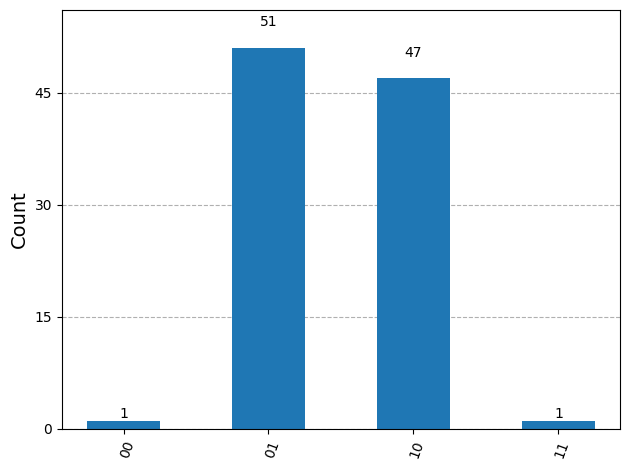

In [11]:
from qiskit.visualization import plot_histogram

print("counts = ", counts)
plot_histogram(counts)

In [22]:
'''
Experiment 2 - Measure energy configuration for the state
psi-minu state = (1/√2) (|10> -|01>) using Estimator
'''
# Import IBM Quantum primitives
from qiskit.quantum_info import SparsePauliOp

# Parameters
J = 1.0  # antiferromagnetic coupling (J<0)
hx = -0.5  # transverse field strength

'''
 Step 1: Define the Hamiltonian H = J Z1 Z2 + hx (X1 + X2)
 SparsePauliOp SparseQ quibit operator that translates Pauli terms into
 observables that quantum computer can measure
 ZZ represents both qubits
 IX and XI qubit 0 and qubit 1
'''
obs = SparsePauliOp.from_list([("ZZ", J), ("XI", hx), ("IX", hx)])

# Make state
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)

# Import IBM Quantum primitives
from qiskit.quantum_info import SparsePauliOp

# Parameters
J = 1.0  # antiferromagnetic coupling (J<0)
hx = -0.5  # transverse field strength

# 1. Define the Hamiltonian H = J Z1 Z2 + hx (X1 + X2)
obs = SparsePauliOp.from_list([("ZZ", J), ("XI", hx), ("IX", hx)])

# Make state
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)

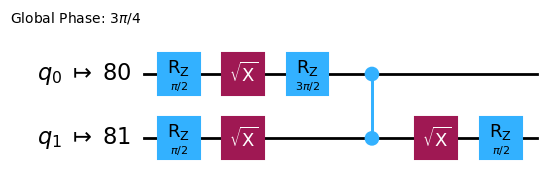

In [13]:
# Optimize

# Transpile the circuit and optimize for running on the quantum computer selected
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)
obs_isa = obs.apply_layout(layout=qc_isa.layout)

qc_isa.draw("mpl")

In [23]:
'''
Import the estimator - service which estimates expectated
values of quantum circuits and observables
Load the Runtime primitive and session
'''
from qiskit_ibm_runtime import EstimatorV2 as Estimator

estimator = Estimator(mode=backend)

In [ ]:
# Load the backend sampler

# noise_model = NoiseModel.from_backend(backend)

# Use Aer simulator in Estimator
# estimator_sim = BackendEstimatorV2(backend=backend_sim)

# Alternatively, load a fake backend with generic properties and define a simulator.
# backend_gen = GenericBackendV2(num_qubits=18)
# estimator_gen = BackendEstimatorV2(backend=backend_gen)

In [15]:
# Run the estimator

pubs = [(qc_isa, obs_isa)]
job = estimator.run([[qc_isa, obs_isa]])
res = job.result()

# Uncomment lines below to run the job on the Aer simulator with noise model from real backend
# job = estimator_sim.run([[qc_isa,obs_isa]])
# res=job.result()

In [18]:
# Post-processing : Print zero th index result from the job.
#This is the energy calculated
print(res[0].data.evs)

-1.0083537454528804
